Saved:
 - phasor_vector_triangle_with_angles.png
 - sinusoid_addition_colored.png


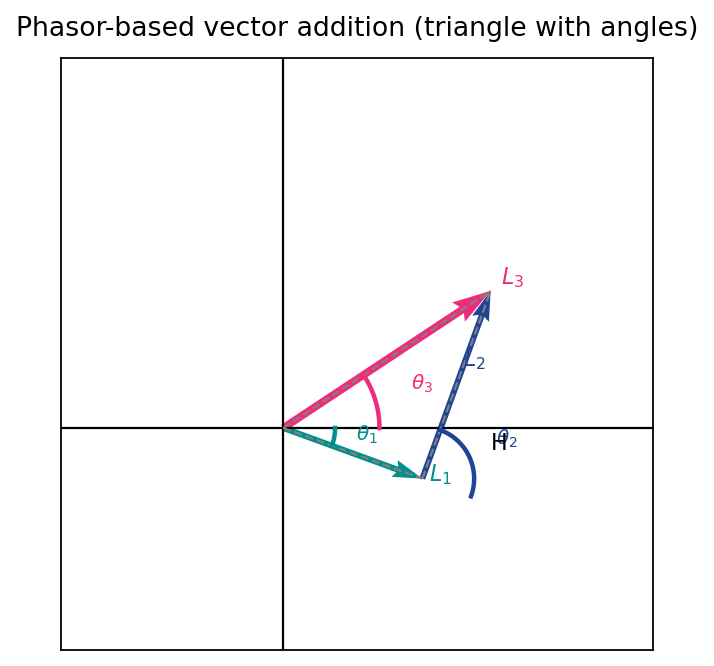

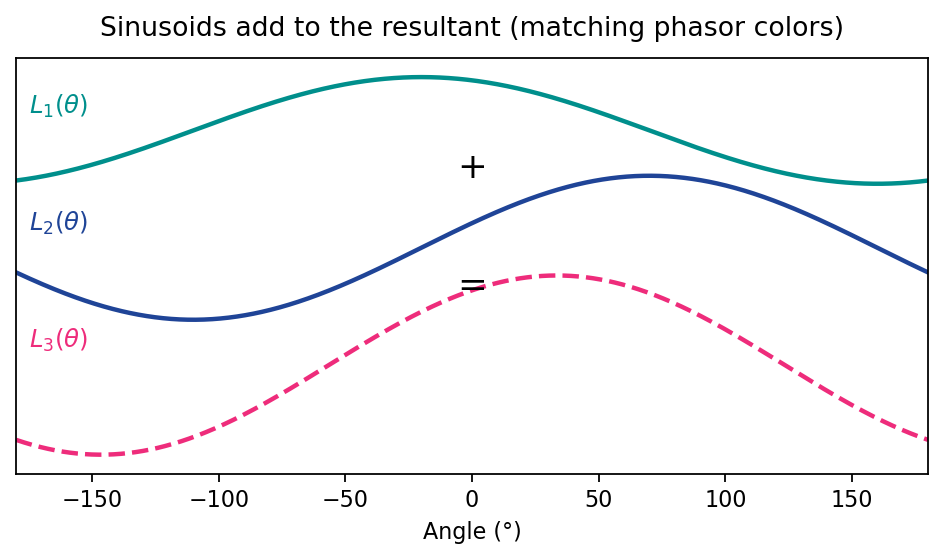

In [7]:
# phasor_vector_and_sinusoid_addition.py
# Generates two figures:
# 1) Triangle-style phasor addition with angle arcs (θ1, θ2, θ3)
# 2) Clean "addition" schematic: L1(θ), L2(θ), and L3(θ)=L1+L2 shown in separate bands

import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Tunable parameters
# -----------------------
theta1 = -20.0   # deg
theta2 = 70.0    # deg
L1 = 1.0         # amplitude / phasor length 1
L2 = 1.35        # amplitude / phasor length 2

# Output paths (change if you like)
OUT_PHASOR = "phasor_vector_triangle_with_angles.png"
OUT_SIN    = "sinusoid_addition_colored.png"

# Unified colors
COL_L1 = "#008f8c"
COL_L2 = "#1f4497"
COL_L3 = "#ee2c7b"

# -----------------------
# Helpers
# -----------------------
def phasor(L, theta_deg):
    """Return complex phasor L · e^{iθ} from amplitude L and angle θ (deg)."""
    return L * np.exp(1j * np.deg2rad(theta_deg))

def sinusoid(L, theta0_deg, x_deg):
    """Cosine with phase θ0 (deg): L * cos(x - θ0)."""
    return L * np.cos(np.deg2rad(x_deg - theta0_deg))

# Compute phasors
z1 = phasor(L1, theta1)
z2 = phasor(L2, theta2)
z3 = z1 + z2
L3 = np.abs(z3)
theta3 = np.rad2deg(np.angle(z3))

# ============================================================
# Figure 1: Phasor triangle (L1 then L2 head-to-tail, L3 closes)
# ============================================================
fig, ax = plt.subplots(figsize=(4, 5), dpi=160)
ax.set_aspect('equal')

# Axes
ax.axhline(0, color="k", linewidth=1)
ax.axvline(0, color="k", linewidth=1)

# L1 from origin
ax.quiver(0, 0, np.real(z1), np.imag(z1),
          angles='xy', scale_units='xy', scale=1,
          width=0.010, color=COL_L1)
# L2 from head of L1
ax.quiver(np.real(z1), np.imag(z1), np.real(z2), np.imag(z2),
          angles='xy', scale_units='xy', scale=1,
          width=0.010, color=COL_L2)
# L3 from origin to head of (L1+L2)
ax.quiver(0, 0, np.real(z3), np.imag(z3),
          angles='xy', scale_units='xy', scale=1,
          width=0.013, color=COL_L3)

# Dashed triangle outline
ax.plot([0, np.real(z1)], [0, np.imag(z1)], linestyle='--', color="gray", linewidth=1)
ax.plot([np.real(z1), np.real(z3)], [np.imag(z1), np.imag(z3)], linestyle='--', color="gray", linewidth=1)
ax.plot([0, np.real(z3)], [0, np.imag(z3)], linestyle='--', color="gray", linewidth=1)

# Angle arcs: θ1 at origin (from 0 to θ1), θ3 at origin (0 to θ3)
def arc(ax, start_deg, end_deg, r, color, lw=2.0):
    t = np.deg2rad(np.linspace(start_deg, end_deg, 100))
    ax.plot(r*np.cos(t), r*np.sin(t), color=color, linewidth=lw)

# θ1
arc(ax, 0, theta1, 0.35, COL_L1)
ax.text(0.5*np.cos(np.deg2rad(theta1/2)),
        0.5*np.sin(np.deg2rad(theta1/2)),
        r"$\theta_1$", color=COL_L1, fontsize=9)

# θ3
arc(ax, 0, theta3, 0.65, COL_L3)
ax.text(0.9*np.cos(np.deg2rad(theta3/2)),
        0.9*np.sin(np.deg2rad(theta3/2)),
        r"$\theta_3$", color=COL_L3, fontsize=9)

# θ2: angle of L2 relative to L1, drawn at L1 tip
phi1 = np.angle(z1)  # radians
phi2 = np.angle(z2)  # radians
t = np.linspace(phi1, phi2, 100)
r = 0.35
ax.plot(np.real(z1) + r*np.cos(t), np.imag(z1) + r*np.sin(t),
        color=COL_L2, linewidth=2)
mid = 0.5*(phi1 + phi2)
ax.text(np.real(z1)+0.55*np.cos(mid),
        np.imag(z1)+0.55*np.sin(mid),
        r"$\theta_2$", color=COL_L2, fontsize=9)

# Labels
ax.text(np.real(z1)*1.05, np.imag(z1)*1.05, r"$L_1$", fontsize=10, color=COL_L1)
ax.text(np.real(z1)+np.real(z2)*0.6, np.imag(z1)+np.imag(z2)*0.6,
        r"$L_2$", fontsize=10, color=COL_L2)
ax.text(np.real(z3)*1.05, np.imag(z3)*1.05, r"$L_3$", fontsize=10, color=COL_L3)
ax.text(1.4, -0.15, "H", fontsize=10)

ax.set_xlim(-1.5, 2.5)
ax.set_ylim(-1.5, 2.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Phasor-based vector addition (triangle with angles)", pad=10)
fig.tight_layout()
#fig.savefig('OUT_PHASOR.svg',format='svg')

# ============================================================
# Figure 2: Sinusoid addition (offset bands, unified colors)
# ============================================================
deg = np.linspace(-180, 180, 1000)
y1 = sinusoid(L1, theta1, deg)
y2 = sinusoid(L2, theta2, deg)
y3 = y1 + y2

offset = 2.2
y1o, y2o, y3o = y1 + offset, y2, y3 - offset

fig2, ax2 = plt.subplots(figsize=(6, 3.6), dpi=160)
ax2.plot(deg, y1o, linewidth=2, color=COL_L1, label=r"$L_1(\theta)$")
ax2.plot(deg, y2o, linewidth=2, color=COL_L2, label=r"$L_2(\theta)$")
ax2.plot(deg, y3o, linewidth=2, linestyle="--", color=COL_L3, label=r"$L_3(\theta)$")

# Baseline reference lines (no background grid)
#ax2.axhline(offset, linewidth=0.8, color="gray")
#ax2.axhline(0.0,     linewidth=0.8, color="gray")
#ax2.axhline(-offset, linewidth=0.8, color="gray")

# Text labels next to each band
ax2.text(-175, offset+0.2, r"$L_1(\theta)$", fontsize=11, va='bottom', color=COL_L1)
ax2.text(-175, 0.2,        r"$L_2(\theta)$", fontsize=11, va='bottom', color=COL_L2)
ax2.text(-175, -offset+0.2,r"$L_3(\theta)$", fontsize=11, va='bottom', color=COL_L3)

# + and = markers to emphasize addition
ax2.text(0, offset-0.9, "+", fontsize=16, ha='center')
ax2.text(0, -0.9,       "=", fontsize=16, ha='center')

ax2.set_xlim(-180, 180)
ax2.set_xlabel("Angle (°)")
ax2.set_yticks([])
ax2.set_title("Sinusoids add to the resultant (matching phasor colors)", pad=10)
ax2.grid(False)
fig2.tight_layout()
#fig2.savefig('OUT_SIN',format='svg')

print(f"Saved:\n - {OUT_PHASOR}\n - {OUT_SIN}")
